# 0.29 — theme monitoring: acceleration & the thresholding argument

The **growth-tracker** step of deck VI: track news **acceleration** for the themes the
birth-detector caught early (**genAI** `chatgpt`, **Crypto ’18** `bitcoin futures`, and
**e-sports** on loose gates), then apply the **calibrated detection thresholds** from the
sibling *Theme-Detection* project.

**Scoring (entity BOW).** A headline is one hit for a theme iff it contains any of the theme's
*entity* words (companies/products/people from 0.28's anchors+partners — verbs/generics dropped,
incumbents kept as-is). Weekly hits → **acceleration** = rolling z.

**Thresholding (three ways, all calibrated on a quiet pre-emergence window):**
1. **Level rule** — `z > 1` for **4 consecutive weeks** (slow, persistent).
2. **Acceleration rule** — `Δz over 4w > 3` in a single week (fast, early, noisier).
3. **Calibration / false-positive control** — on the quiet window z should be ~N(0,1) and
   *neither* rule should fire; then we apply out-of-sample and read off the first fire.

> **Memory note.** Vocabs hard-coded; only the light streaming hit-count runs (~1 GB).
> **Entity caveat.** Keeping incumbents (`google`, `microsoft`, `alibaba`) dilutes genAI — the
> thresholding below *quantifies* that (its calibration window shows a high false-positive rate),
> which is the argument for filtering pre-existing entities upstream in discovery.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from theme_monitor import (weekly_theme_hits_from_parquet, acceleration_score,
                            acceleration_delta, level_rule, accel_rule, first_fire,
                            calibration_stats)

CORPUS = Path.cwd().parent / "notebooks" / "output" / "news_corpus.parquet"
assert CORPUS.exists(), CORPUS
pd.set_option("display.width", 200)

## 1 · Themes, entity BOW, and calibration windows

In [2]:
# ENTITY words from 0.28's discovery output (anchors + partners): every company/product/
# person kept, only verbs / generic nouns / truncation fragments removed. Windows are
# widened so each theme has a genuine QUIET calibration period before its emergence.
THEMES = {
    "genAI (ChatGPT)": dict(vocab=['alibaba', 'altman', 'baidu', 'chatgpt', 'chatgpt-like', 'chatgpt-style', 'ernie', 'google', 'jpmorgan', 'microsoft', 'netease', 'nvidia', 'openai'],
        window=("2021-01-01", "2023-05-18"), calib=("2021-04-01", "2022-09-30"),
        etf=("CHAT", "2023-05-18"), promote="2023-01-17"),
    "Crypto \u201918": dict(vocab=['bitcoin', 'blockchain', 'cboe', 'cme', 'coinbase', 'crypto', 'cryptocurrency', 'hive', 'ico', 'natixis', 'riot'],
        window=("2015-06-01", "2018-03-31"), calib=("2015-09-01", "2017-06-30"),
        etf=("BLOK", "2018-01-17"), promote="2017-11-28"),
    "e-sports": dict(vocab=['activision', 'espn', 'esports', 'e-sports', 'mlg', 'usmanov', 'yahoo'],
        window=("2013-06-01", "2016-12-31"), calib=("2013-09-01", "2015-06-30"),
        etf=("GAMR", "2016-03-09"), promote="2016-03-01"),
}
# Detection parameters (Theme-Detection defaults, verbatim)
Z_THRESHOLD, N_CONSECUTIVE = 1.0, 4       # LEVEL rule: z > 1 for 4 consec weeks
ACCEL_LAG, ACCEL_THRESHOLD = 4, 3.0       # ACCEL rule: (z - z.shift(4)) > 3 in one week
for k, v in THEMES.items():
    print(f"{k:16s} {len(v['vocab'])} entities · calib {v['calib'][0]}..{v['calib'][1]}")

genAI (ChatGPT)  13 entities · calib 2021-04-01..2022-09-30
Crypto ’18       11 entities · calib 2015-09-01..2017-06-30
e-sports         7 entities · calib 2013-09-01..2015-06-30


## 2 · Score — weekly entity hits → acceleration z (and its Δz)

`weekly_theme_hits_from_parquet` streams the corpus once per theme; `acceleration_score`
takes the rolling z; `acceleration_delta` its 4-week change.

In [3]:
results = {}
for name, cfg in THEMES.items():
    d0, d1 = cfg['window']
    hits = weekly_theme_hits_from_parquet(CORPUS, cfg['vocab'], d0, d1)
    z = acceleration_score(pd.DataFrame({name: hits}), roll_weeks=12, min_periods=4)[name]
    results[name] = pd.DataFrame({'hits': hits, 'z': z,
                                  'z_accel': acceleration_delta(z, ACCEL_LAG)})
    print(f"{name:16s} peak {int(hits.max()):5d} hits/wk · z peak {z.max():.2f} at {z.idxmax().date()}")

genAI (ChatGPT)  peak   358 hits/wk · z peak 2.84 at 2021-11-16


Crypto ’18       peak   302 hits/wk · z peak 2.92 at 2017-11-28


e-sports         peak   172 hits/wk · z peak 2.94 at 2015-01-27


## 3 · Calibration — does the signal behave like N(0,1) on the quiet window?

By construction the rolling z should have **mean ≈ 0, std ≈ 1** on a quiet period, and a
well-set threshold should fire **~0 times** there. A high `frac_z>1` / nonzero `level_fires`
means the theme's baseline is too noisy for the threshold — the false-positive warning.

In [4]:
calib = pd.DataFrame({
    name: calibration_stats(r['z'], *THEMES[name]['calib'],
                            threshold=Z_THRESHOLD, n_consecutive=N_CONSECUTIVE,
                            accel_lag=ACCEL_LAG, accel_threshold=ACCEL_THRESHOLD)
    for name, r in results.items()}).T
calib

,weeks,mean_z,std_z,frac_z>1,frac_z>1.5,max_z,level_fires,accel_fires
genAI (ChatGPT),78.0,-0.11,0.97,0.13,0.08,2.84,0.0,1.0
Crypto ’18,96.0,0.05,0.95,0.16,0.09,2.53,0.0,1.0
e-sports,96.0,-0.05,0.93,0.10,0.07,2.94,0.0,3.0


## 4 · Apply the detection rules — first fire vs the theme's ETF/promote dates

Both rules are applied to the full window; the first fire is read **after** the calibration
window. `lead_days` = days the fire precedes the theme's ETF birth (positive = news leads).

In [5]:
rows = []
for name, r in results.items():
    cfg = THEMES[name]
    post = cfg['calib'][1]
    lvl = level_rule(r['z'], Z_THRESHOLD, N_CONSECUTIVE)
    acc = accel_rule(r['z_accel'], ACCEL_THRESHOLD)
    fl, fa = first_fire(lvl, after=post), first_fire(acc, after=post)
    etf = pd.Timestamp(cfg['etf'][1])
    rows.append({'theme': name, 'ETF': cfg['etf'][0], 'ETF_date': etf.date(),
                 'promote_wk': cfg['promote'],
                 'level_first_fire': fl.date() if fl is not None else None,
                 'level_lead_days': (etf - fl).days if fl is not None else None,
                 'accel_first_fire': fa.date() if fa is not None else None,
                 'accel_lead_days': (etf - fa).days if fa is not None else None})
fires = pd.DataFrame(rows).set_index('theme')
fires

,ETF,ETF_date,promote_wk,level_first_fire,level_lead_days,accel_first_fire,accel_lead_days
theme,,,,,,,
genAI (ChatGPT),CHAT,2023-05-18,2023-01-17,None,None,2023-01-17,121
Crypto ’18,BLOK,2018-01-17,2017-11-28,None,None,2017-08-01,169
e-sports,GAMR,2016-03-09,2016-03-01,None,None,2015-10-20,141


## 5 · The thresholding picture — one panel per theme

Blue = acceleration z; dashed red = level threshold (+1); grey band = calibration window;
red shading = weeks the **level rule** fires; purple ▲ = **acceleration-rule** fires;
green line = funnel promote week; dotted black = ETF birth.

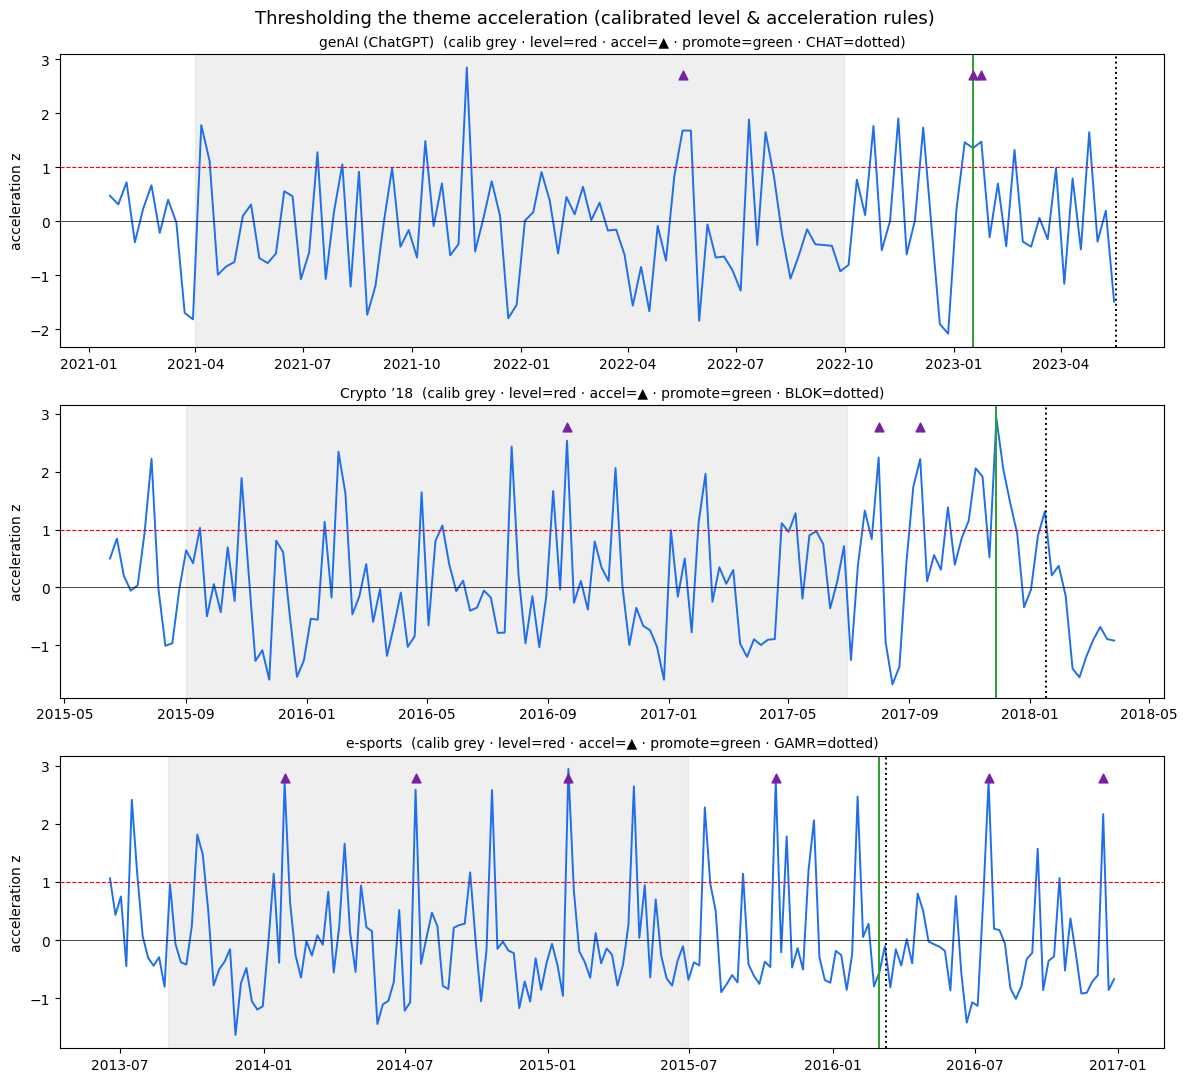

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11))
for ax, (name, r) in zip(axes, results.items()):
    cfg = THEMES[name]
    ax.plot(r.index, r['z'], color='#1f6feb', lw=1.4)
    ax.axhline(Z_THRESHOLD, color='red', ls='--', lw=0.8); ax.axhline(0, color='k', lw=0.5)
    ax.axvspan(pd.Timestamp(cfg['calib'][0]), pd.Timestamp(cfg['calib'][1]),
               color='grey', alpha=0.12)
    lvl = level_rule(r['z'], Z_THRESHOLD, N_CONSECUTIVE)
    for d in r.index[lvl.fillna(False)]:
        ax.axvline(d, color='red', alpha=0.18, lw=2)
    acc = accel_rule(r['z_accel'], ACCEL_THRESHOLD)
    fa = r.index[acc.fillna(False)]
    ax.scatter(fa, [r['z'].max()*0.95]*len(fa), marker='^', color='#7a1fa2', s=40, zorder=5)
    ax.axvline(pd.Timestamp(cfg['promote']), color='#2ca02c', lw=1.4)
    ax.axvline(pd.Timestamp(cfg['etf'][1]), color='k', ls=':', lw=1.4)
    ax.set_title(f"{name}  (calib grey · level=red · accel=\u25b2 · promote=green · {cfg['etf'][0]}=dotted)",
                 fontsize=10)
    ax.set_ylabel('acceleration z')
fig.suptitle('Thresholding the theme acceleration (calibrated level & acceleration rules)', fontsize=13)
plt.tight_layout(); plt.show()

### The acceleration signal (Δz) with the +3 rule line

The second-derivative panel Theme-Detection plots beneath the z-score: purple = Δz over 4
weeks, dashed line = the acceleration threshold (+3) the ▲ fires must cross.

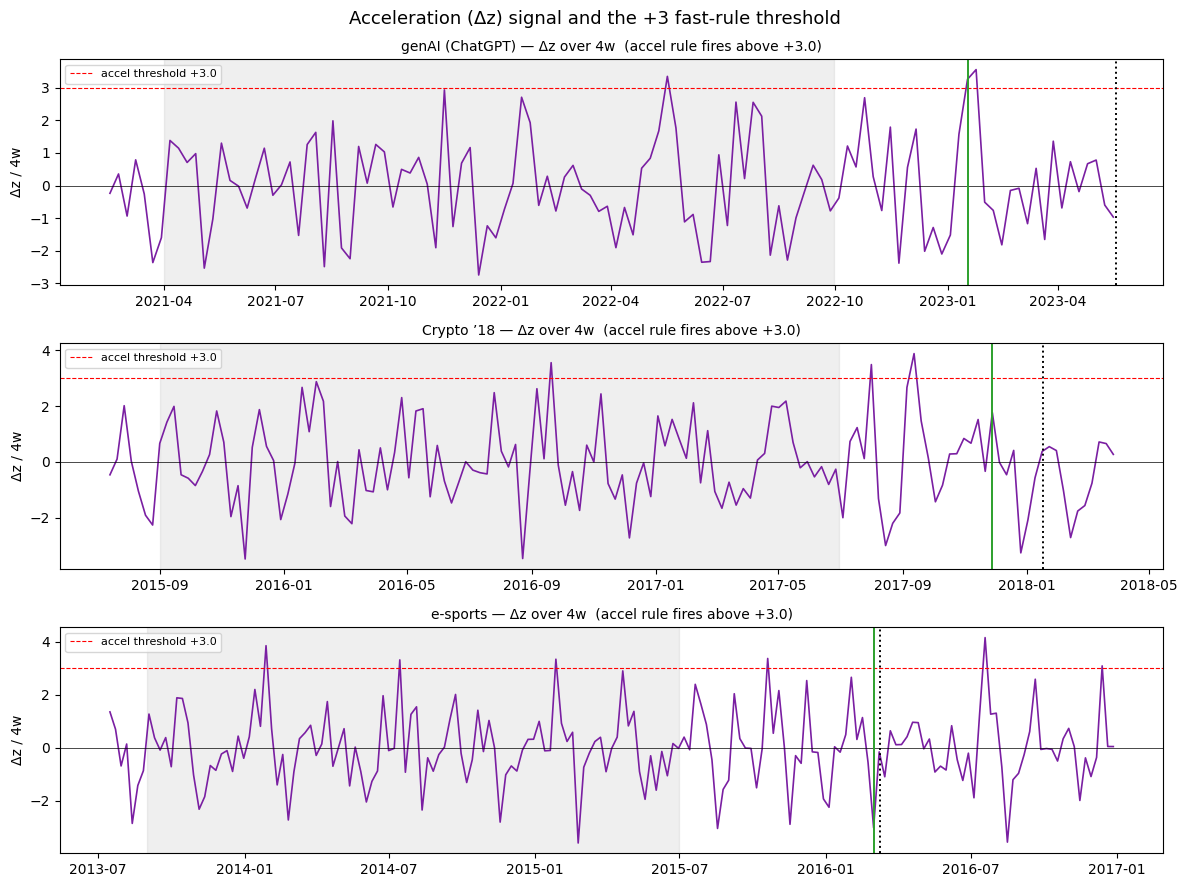

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for ax, (name, r) in zip(axes, results.items()):
    cfg = THEMES[name]
    ax.plot(r.index, r['z_accel'], color='#7a1fa2', lw=1.2)
    ax.axhline(ACCEL_THRESHOLD, color='red', ls='--', lw=0.8, label=f'accel threshold +{ACCEL_THRESHOLD}')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvspan(pd.Timestamp(cfg['calib'][0]), pd.Timestamp(cfg['calib'][1]), color='grey', alpha=0.12)
    ax.axvline(pd.Timestamp(cfg['promote']), color='#2ca02c', lw=1.4)
    ax.axvline(pd.Timestamp(cfg['etf'][1]), color='k', ls=':', lw=1.4)
    ax.set_title(f"{name} — Δz over {ACCEL_LAG}w  (accel rule fires above +{ACCEL_THRESHOLD})", fontsize=10)
    ax.set_ylabel(f'\u0394z / {ACCEL_LAG}w'); ax.legend(loc='upper left', fontsize=8)
fig.suptitle('Acceleration (Δz) signal and the +3 fast-rule threshold', fontsize=13)
plt.tight_layout(); plt.show()

### Calibration false-positive rates (visual)

The tabular calibration from §3 as a bar chart: fraction of quiet-window weeks above z=1 and
z=1.5. Low bars ⇒ the level threshold is safely above the theme's quiet-period noise.

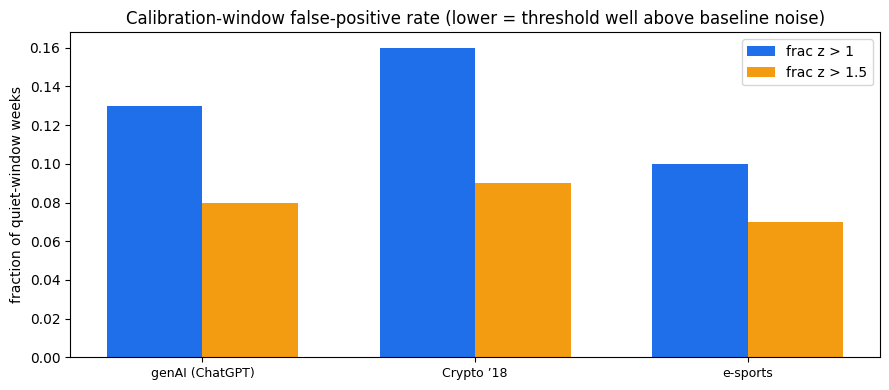

In [8]:
x = np.arange(len(calib)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, calib['frac_z>1'].astype(float), w, label='frac z > 1', color='#1f6feb')
ax.bar(x + w/2, calib['frac_z>1.5'].astype(float), w, label='frac z > 1.5', color='#f39c12')
ax.set_xticks(x); ax.set_xticklabels(calib.index, fontsize=9)
ax.set_ylabel('fraction of quiet-window weeks'); ax.legend()
ax.set_title('Calibration-window false-positive rate (lower = threshold well above baseline noise)')
plt.tight_layout(); plt.show()

## 6 · Persist (optional)

In [9]:
OUT = Path.cwd().parent / "data" / "processed"
OUT.mkdir(parents=True, exist_ok=True)
panel = pd.concat({n: r for n, r in results.items()}, axis=1)
panel.to_parquet(OUT / "theme_monitor_bow_panel.parquet")
calib.to_parquet(OUT / 'theme_monitor_calibration.parquet')
fires.to_parquet(OUT / 'theme_monitor_detection_fires.parquet')
print("wrote panel", panel.shape, "+ calibration + detection_fires tables")

wrote panel (378, 9) + calibration + detection_fires tables
